In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.cosmology.baccoemu_cosmology import BACCOemuLinearPerturbations, BACCOemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [2]:
# Get n(z)
#data_path = 'TR1_data/'
#z_nz_pos, nz_pos = el.phz.redshift_distributions(data_path+'TR1_v1_Nz_GC_C2020_sel_pv.fits')
#z_nz_she, nz_she = el.phz.redshift_distributions(data_path+'TR1_v1_Nz_WL_C2020_sel_pv.fits')

data_path = 'scale_cut_data/'
z_nz_pos, nz_pos = el.phz.redshift_distributions(data_path+'South_positions_nz_euclidlib.fits')
z_nz_she, nz_she = el.phz.redshift_distributions(data_path+'South_shear_nz_euclidlib.fits')
print('z arrays: ',z_nz_pos.shape, z_nz_she.shape)

# Normalize and resample n(z) for both position and shear
zs = np.linspace(1e-4, 3.0, 128)
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_pos, z_nz_pos)
dndz_she_norm = normalize_dndz(nz_she, z_nz_she)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz_pos, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz_she, zs)


z arrays:  (3001,) (3001,)


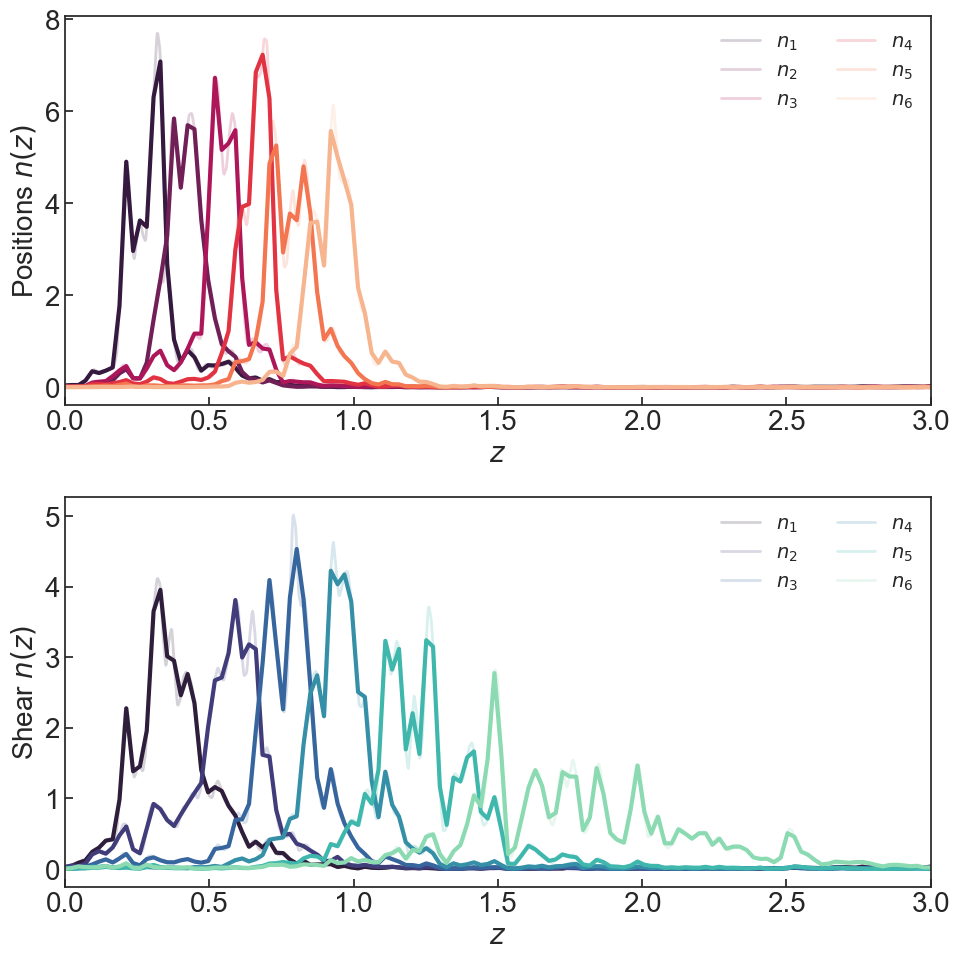

In [3]:
# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz_pos, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color, alpha=0.2)

for i in range(6):
    axs[0].plot(zs, my_dndz_pos_norm[i], color=sns.color_palette("rocket", len(dndz_pos_norm))[i])

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz_she, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color, alpha=0.2)

for i in range(6):
    axs[1].plot(zs, my_dndz_she_norm[i], color=sns.color_palette("mako", len(dndz_she_norm))[i])

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 3)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 3)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
#abacus cosmology
fiducial_cosmology = {
    'H0': 62.78,                # Hubble constant
    'Omega_cdm0': 0.3044659,        # Cold dark matter density
    'Omega_b0': 0.0567575,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.06,                # Neutrino mass
    'w0': -0.7,                # Dark energy equation of state (present)
    'wa': -0.5,                 # Dark energy equation of state (evolution)
    'ns': 0.9649,                # Scalar spectral index
    'As': 2.314e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    #'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    #'N_eff': 3.046             # Effective number of relativistic species
    'N_ur': 2.0308 #2.0328,
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    #'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    #'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    #1.14, 1.25, 1.40, 1.45, 1.60, 1.75
    'b1_photo_bin0': 1.14, 'b1_photo_bin1': 1.25,
    'b1_photo_bin2': 1.40, 'b1_photo_bin3': 1.45,
    'b1_photo_bin4': 1.60, 'b1_photo_bin5': 1.75,

    # Magnification bias (per bin)
    #0.69, 0.68, 0.79, 0.89, 1.20, 2.18
    'magnification_bias_1': 0.69, 'magnification_bias_2': 0.68,
    'magnification_bias_3': 0.79, 'magnification_bias_4': 0.89,
    'magnification_bias_5': 1.20, 'magnification_bias_6': 2.18,

    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    'width_pos_1': 1.0, 'width_pos_2': 1.0,
    'width_pos_3': 1.0, 'width_pos_4': 1.0,
    'width_pos_5': 1.0, 'width_pos_6': 1.0,

    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,

    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'width_shear_1': 1.0, 'width_shear_2': 1.0,
    'width_shear_3': 1.0, 'width_shear_4': 1.0,
    'width_shear_5': 1.0, 'width_shear_6': 1.0

}

#32 modes
ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

nell = len(ell_theory)
ell_theory_diff = ell_theory[1:]-ell_theory[:-1]

In [5]:
background_cpl = CAMBBackground(H0=fiducial_cosmology['H0'], 
                            Omega_cdm0=fiducial_cosmology['Omega_cdm0'], 
                            Omega_b0=fiducial_cosmology['Omega_b0'], 
                            w0=fiducial_cosmology['w0'], 
                            wa=fiducial_cosmology['wa'], 
                            Omega_k0 = fiducial_cosmology['Omega_k0'], 
                            ns = fiducial_cosmology['ns'], 
                            As = fiducial_cosmology['As'],
                            mnu = fiducial_cosmology['mnu'],
                            gamma_MG = fiducial_cosmology['gamma_MG'],
                            N_mnu=fiducial_cosmology['N_mnu'],
                            N_ur=fiducial_cosmology['N_ur'])
background_lcdm = CAMBBackground(H0=fiducial_cosmology['H0'], 
                            Omega_cdm0=fiducial_cosmology['Omega_cdm0'], 
                            Omega_b0=fiducial_cosmology['Omega_b0'], 
                            w0=-1., 
                            wa=0., 
                            Omega_k0 = fiducial_cosmology['Omega_k0'], 
                            ns = fiducial_cosmology['ns'], 
                            As = fiducial_cosmology['As'],
                            mnu = fiducial_cosmology['mnu'],
                            gamma_MG = fiducial_cosmology['gamma_MG'],
                            N_mnu=fiducial_cosmology['N_mnu'],
                            N_ur=fiducial_cosmology['N_ur'])

In [6]:
linear_perturbations_cpl_hmcode = HMemuLinearPerturbations(background_cpl, zs)
nonlinear_perturbations_cpl_hmcode = HMemuNonLinearPerturbations(background_cpl, linear_perturbations_cpl_hmcode, zs, log10TAGN=None)
linear_perturbations_lcdm_hmcode = HMemuLinearPerturbations(background_lcdm, zs)
nonlinear_perturbations_lcdm_hmcode = HMemuNonLinearPerturbations(background_lcdm, linear_perturbations_lcdm_hmcode, zs, log10TAGN=None)


linear_perturbations_cpl_bacco = BACCOemuLinearPerturbations(background_cpl, zs)
nonlinear_perturbations_cpl_bacco = BACCOemuNonLinearPerturbations(background_cpl, linear_perturbations_cpl_bacco, zs, "Arico2023", None)


for kmax = 0.06 1/Mpc
bin 1 - lmax = 65.81
bin 2 - lmax = 76.51
bin 3 - lmax = 85.01
bin 4 - lmax = 95.92
bin 5 - lmax = 98.31
bin 6 - lmax = 105.43
for kmax = 0.19 1/Mpc
bin 1 - lmax = 197.43
bin 2 - lmax = 229.52
bin 3 - lmax = 255.03
bin 4 - lmax = 287.76
bin 5 - lmax = 294.92
bin 6 - lmax = 316.29


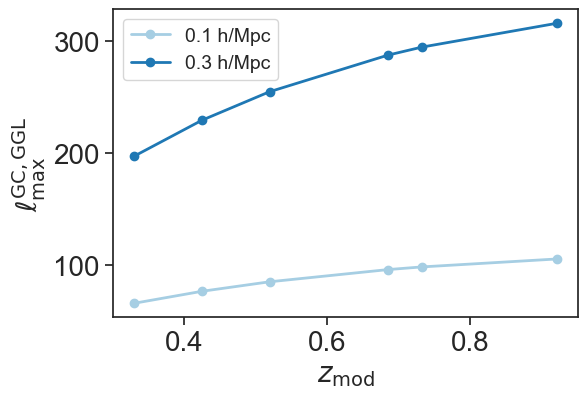

In [9]:
z_mod = []
comdis_mod = []
tracer_pos = PositionsTracer(
        perturbations=nonlinear_perturbations_cpl_hmcode,
        dndz=my_dndz_pos_norm,
        z=zs,
        galaxy_bias_model='per_bin',
        nuisance_params=fiducial_nuisance
    ) 
tracer_shear = ShearTracer(
        perturbations=nonlinear_perturbations_cpl_hmcode,
        dndz=my_dndz_she_norm,
        z=zs,
        nuisance_params=fiducial_nuisance,
        ia_model='NLA'
    ) 

for i in range(6):
    ind = np.argmax(tracer_pos.get_window(nonlinear_perturbations_cpl_hmcode.z)[i, :])
    zmod = nonlinear_perturbations_cpl_hmcode.z[ind]
    z_mod.append(zmod)
    comdismod = nonlinear_perturbations_cpl_hmcode.background.comoving_distance((nonlinear_perturbations_cpl_hmcode.z))[ind]
    comdis_mod.append(comdismod)

def from_kmax_to_lmax(kmax):
    print(f'for kmax = {kmax:.2f} 1/Mpc')
    lmax_list = [kmax * comdis / (1 + z) for comdis, z in zip(comdis_mod, z_mod)]
    for i, lmax in enumerate(lmax_list, start=1):
        print(f'bin {i} - lmax = {lmax:.2f}')
    return lmax_list

lmax_0p1 = from_kmax_to_lmax(nonlinear_perturbations_cpl_hmcode.background.h * 0.1)
lmax_0p3 = from_kmax_to_lmax(nonlinear_perturbations_cpl_hmcode.background.h * 0.3)

# Create the figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(z_mod, lmax_0p1, label='0.1 h/Mpc', linewidth=2, fmt='-o')
ax.errorbar(z_mod, lmax_0p3, label='0.3 h/Mpc', linewidth=2, fmt='-o')
ax.legend()
ax.set_xlabel(r'$z_{\rm mod}$')
ax.set_ylabel(r'$\ell_{\rm max}^{\rm GC,GGL}$')
plt.show()

# CPL BACCO vs HMcode2020

In [10]:
def compute_cells(perturbations):
    # Tracer definitions (easy to swap dndz, bias model, etc.)
    tracer_pos = PositionsTracer(
        perturbations=perturbations,
        dndz=my_dndz_pos_norm,
        z=zs,
        galaxy_bias_model='per_bin',
        nuisance_params=fiducial_nuisance
    )
    
    tracer_she = ShearTracer(
        perturbations=perturbations,
        dndz=my_dndz_she_norm,
        z=zs,
        nuisance_params=fiducial_nuisance,
        ia_model='NLA'
    )
    # 🎯 Compute all the 2-point angular power spectra in one go!
    cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
    cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
    cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)
    return cls_sheshe, cls_posshe, cls_pospos

In [11]:
cells_wl = {}
cells_ggl = {}
cells_gc = {}
labels = ['contaminated', 'baseline']
labels_names = ['contaminated (bacco)', 'baseline (hmcode)']

In [12]:
nonlinear_perturbations_contaminated = nonlinear_perturbations_cpl_bacco
nonlinear_perturbations_baseline = nonlinear_perturbations_cpl_hmcode

for label in labels:
    perturbations = eval(f'nonlinear_perturbations_{label}')
    cells_wl[label], cells_ggl[label], cells_gc[label] = compute_cells(perturbations)

In [13]:
full_cov=np.load(data_path+'covariance_Gauss_Euclid_DR1_TR1_v2.0_2D.npz')['Gauss']

print('full cov: ', full_cov.shape)
# Extract weak lensing covariance submatrix
# Shape: (n_tomographic_pairs * n_ell_bins, n_tomographic_pairs * n_ell_bins)
# For 6 bins: (21+21)*32 = 1344 elements (EE + BB correlations)
n_she_bins = len(nz_she)
shear_pairs = int(n_she_bins*(n_she_bins+1)/2)

n_pos_bins = len(nz_pos)
pos_pairs = int(n_pos_bins*(n_pos_bins+1)/2)

cov_WL = full_cov[:shear_pairs*nell, :shear_pairs*nell]
print('WL cov: ', cov_WL.shape)

cov_GC = full_cov[-pos_pairs*nell:, -pos_pairs*nell:]
print('GC cov: ', cov_GC.shape)

cov_GGL = full_cov[shear_pairs*nell:-pos_pairs*nell, shear_pairs*nell:-pos_pairs*nell]
print('GGL cov: ', cov_GGL.shape)

full cov:  (2496, 2496)
WL cov:  (672, 672)
GC cov:  (672, 672)
GGL cov:  (1152, 1152)


In [14]:
errors_wl = np.sqrt(np.diag(cov_WL))
pairs_wl = []
for i in range(n_she_bins):
    for j in range(i+1):
        pairs_wl.append((i, j))
WL_keys = [
            ("SHE", "SHE", i, j)
            for i in range(1, n_she_bins + 1)
            for j in range(i, n_she_bins + 1)
        ]

bin 11: chi2=0.2827854002961686 with ell_max_start=3000; chi2_new=0.2827854002961686 ell_max=2755.10835283
bin 21: chi2=0.86788118883605 with ell_max_start=3000; chi2_new=0.86788118883605 ell_max=2755.10835283
bin 22: chi2=1.670349677060115 with ell_max_start=3000; chi2_new=1.4356163392973762 ell_max=1350.51224608
bin 31: chi2=0.9751445981271254 with ell_max_start=3000; chi2_new=0.9751445981271254 ell_max=2755.10835283
bin 32: chi2=2.188204349122681 with ell_max_start=3000; chi2_new=1.2427304138905269 ell_max=945.53682628
bin 33: chi2=3.543638132989846 with ell_max_start=3000; chi2_new=1.13489464626481 ell_max=791.16744571
bin 41: chi2=0.6847775078971068 with ell_max_start=3000; chi2_new=0.6847775078971068 ell_max=2755.10835283
bin 42: chi2=3.179838355844491 with ell_max_start=3000; chi2_new=1.3658443271736622 ell_max=791.16744571
bin 43: chi2=5.8966600768307424 with ell_max_start=3000; chi2_new=1.1722444861569685 ell_max=662.00057974
bin 44: chi2=7.830765426343943 with ell_max_start=3

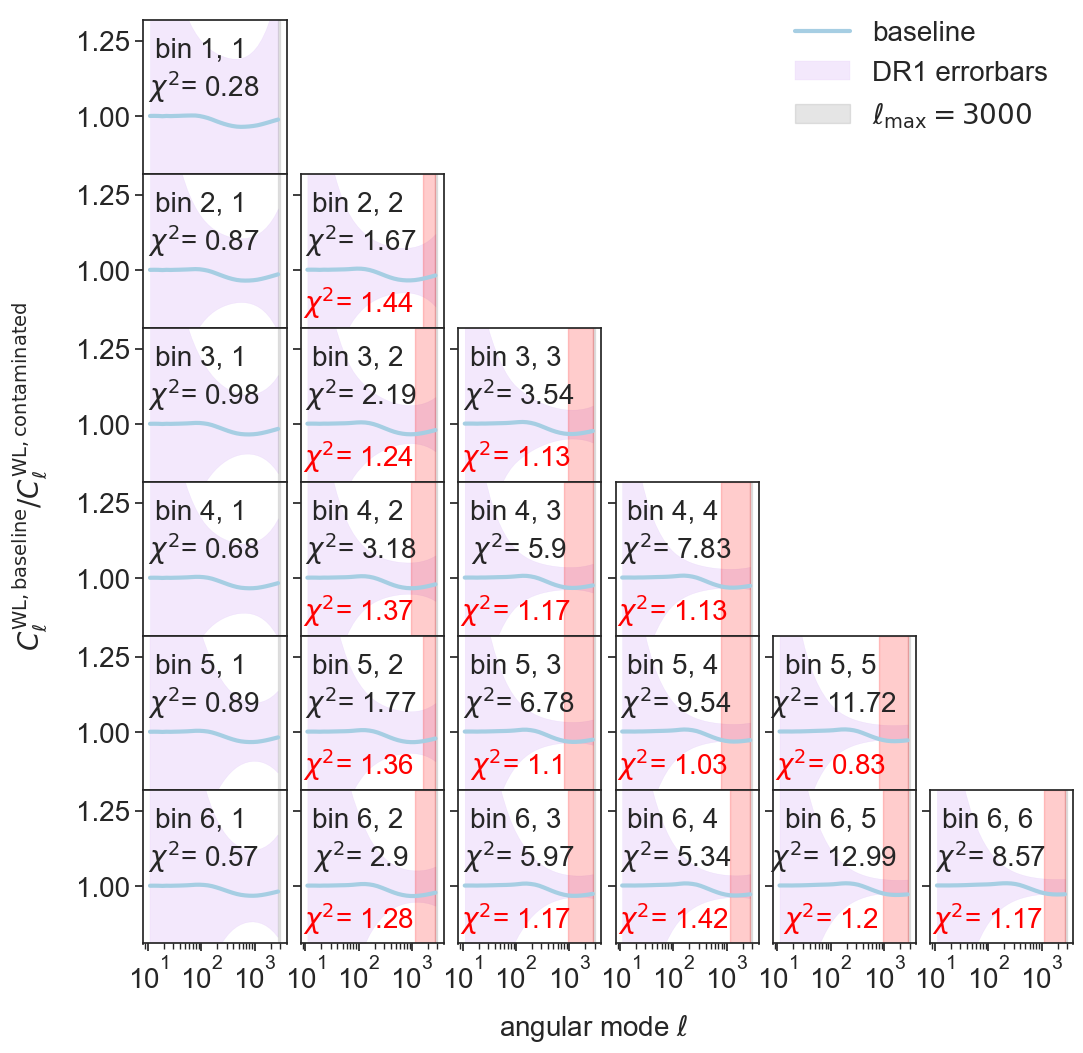

In [15]:
ell_max_start = 3000
chi2_max_ij = 1.5
fig, ax = plt.subplots(n_she_bins, n_she_bins, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(n_she_bins):
    for j in range(n_she_bins):
        if i >= j:
            # find index of this pair
            p = pairs_wl.index((i, j))
            start = p * nell
            end = (p + 1) * nell
            err = errors_wl[start:end]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            y = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            ax[i,j].semilogx(ell_theory,  y)

            diff = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]-cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            mask = ell_theory<ell_max_start
            chi2 = np.sum(diff[mask]**2/errors_wl[start:end][mask]**2)
            n = 1
            chi2_new = chi2
            mask_new = ell_theory < ell_max_start
            if chi2>chi2_max_ij:
                while chi2_new>chi2_max_ij:
                    mask_new = ell_theory < (ell_max_start - n)
                    chi2_new = np.sum(diff[mask_new]**2/errors_wl[start:end][mask_new]**2)
                    n +=1
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )

            ax[i,j].text(.4, .5, 'bin %s, %s\n $\\chi^2$= %s'%(str(i+1),(j+1), round(chi2, 2)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=3000, xmax=ell_theory[-1], color='grey', alpha=0.2)
            ax[i, j].set_ylim(0.81, 1.32)
            print(f"bin {i+1}{j+1}: chi2={chi2} with ell_max_start={ell_max_start}; chi2_new={chi2_new} ell_max={ell_theory[mask_new][-1]}")
       
            if chi2_new != chi2:
                ax[i,j].text(.4, .1, '$\\chi^2$= %s'%(round(chi2_new, 2)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes, color='red')
                ax[i, j].axvspan(xmin=ell_max_start - n, xmax=ell_theory[-1], color='red', alpha=0.2)
                
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm WL, baseline}_{\ell}/C^{\rm WL, contaminated}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(['baseline', 'DR1 errorbars', '$\\ell_{\\rm max}=3000$'],  loc='upper right', ncol=1, bbox_to_anchor=(0.9, 0.9), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)

In [16]:
data = np.array(
            [cells_wl['contaminated'][key][0, 0] for key in WL_keys]
        ).flatten()
theory = np.array(
            [cells_wl['baseline'][key][0, 0] for key in WL_keys]
        ).flatten()
C = cov_WL

diff = theory - data
invC = np.linalg.inv(C)

chi2 = diff @ invC @ diff
chi2

np.float64(35.5571233687858)

In [17]:
# Per-point chi^2 contribution for each tomographic bin pair.
# Using the full-cov decomposition:  chi2 = sum_i diff_i * (invC @ diff)_i
v = invC @ diff
chi2_per_point = diff * v  # shape: (n_pairs * nell,)
assert np.isclose(chi2_per_point.sum(), chi2), "per-point sum must match total chi2"
chi2_contribution = {}
for p, key in enumerate(WL_keys):
    _, _, i, j = key
    start = p * nell
    end = (p + 1) * nell
    chi2_contribution[f"bin {i}{j}"] = {
        "ell":  ell_theory.tolist(),
        "chi2": chi2_per_point[start:end].tolist(),
    }
print(f"Total chi2                       = {chi2:.4f}")
print(f"Sum of per-point contributions   = "
      f"{sum(sum(b['chi2']) for b in chi2_contribution.values()):.4f}")
for bin_label, vals in chi2_contribution.items():
    print(f"  {bin_label}: chi2 = {sum(vals['chi2']):.4f}")


Total chi2                       = 35.5571
Sum of per-point contributions   = 35.5571
  bin 11: chi2 = 0.1137
  bin 12: chi2 = 0.3106
  bin 13: chi2 = 0.3340
  bin 14: chi2 = 0.3099
  bin 15: chi2 = 0.2602
  bin 16: chi2 = 0.1885
  bin 22: chi2 = 0.3072
  bin 23: chi2 = 0.8528
  bin 24: chi2 = 0.9203
  bin 25: chi2 = 0.9082
  bin 26: chi2 = 0.8393
  bin 33: chi2 = 0.7706
  bin 34: chi2 = 1.9621
  bin 35: chi2 = 2.2412
  bin 36: chi2 = 2.4220
  bin 44: chi2 = 1.4194
  bin 45: chi2 = 3.5947
  bin 46: chi2 = 4.2384
  bin 55: chi2 = 2.5114
  bin 56: chi2 = 6.4145
  bin 66: chi2 = 4.6380


In [18]:
chi2_max = 1.5

# Tag every global data-vector index with (bin_label, ell, bin_idx, ell_idx).
# bin_idx is the position of the (i, j) pair inside WL_keys; ell_idx is the
# index into ell_theory.  This lets us enforce the "remove only from the
# high-ell end of each bin" constraint, so kept ells stay contiguous from
# l_min upward in every bin.
point_tags = []
for p, key in enumerate(WL_keys):
    _, _, i, j = key
    bin_label = f"bin {i}{j}"
    for k, ell_val in enumerate(ell_theory):
        point_tags.append((bin_label, float(ell_val), p, k))

keep_mask = np.ones(len(diff), dtype=bool)

def chi2_with_mask(mask):
    """Recompute chi2 and per-point contributions on the *kept* subset by
    inverting the corresponding sub-covariance."""
    d_sub    = diff[mask]
    C_sub    = C[np.ix_(mask, mask)]
    invC_sub = np.linalg.inv(C_sub)
    v_sub    = invC_sub @ d_sub
    return d_sub @ v_sub, d_sub * v_sub

chi2_cur, per_point_cur = chi2_with_mask(keep_mask)
print(f"Initial chi2 = {chi2_cur:.4f}   (n_points = {keep_mask.sum()})\n")

# For every bin (position p in WL_keys), track its highest currently kept
# ell-index.  Only that point is eligible for removal at any step.
highest_kept = {p: nell - 1 for p in range(len(WL_keys))}

removed = []
max_iter = len(diff)  # safety cap

while chi2_cur > chi2_max and len(removed) < max_iter:
    # Map per-point contributions (over kept subarray) back to global indices.
    active_global  = np.where(keep_mask)[0]
    contrib_global = np.full(len(diff), -np.inf)
    contrib_global[active_global] = per_point_cur

    # Candidates: for each bin still having points, the contribution at its
    # current highest-ell index.
    candidates = []
    for p, k_top in highest_kept.items():
        if k_top is None:
            continue
        g = p * nell + k_top
        candidates.append((contrib_global[g], g, p, k_top))

    if not candidates:
        print("All points removed; stopping.")
        break

    # Pick the eligible high-ell point with the largest chi2 contribution.
    best_contrib, worst_global, p, k_top = max(candidates, key=lambda t: t[0])

    if best_contrib <= 0:
        print("No high-ell candidate has positive chi2 contribution; stopping.")
        break

    bin_label, ell_val, _, _ = point_tags[worst_global]
    keep_mask[worst_global] = False
    highest_kept[p] = k_top - 1 if k_top > 0 else None

    chi2_cur, per_point_cur = chi2_with_mask(keep_mask)

    removed.append({
        "bin":        bin_label,
        "ell":        ell_val,
        "chi2_after": float(chi2_cur),
    })
    print(f"  removed {bin_label:>8s}, ell = {ell_val:10.4f}  "
          f"->  new chi2 = {chi2_cur:.4f}   "
          f"(n_points left = {keep_mask.sum()})")

print(f"\nFinal chi2 = {chi2_cur:.4f}  after removing {len(removed)} points "
      f"(threshold = {chi2_max}).")

# Per-bin ell_max after the cut, handy for downstream use.
ell_max_per_bin = {}
for p, key in enumerate(WL_keys):
    _, _, i, j = key
    k_top = highest_kept[p]
    ell_max_per_bin[f"bin {i}{j}"] = float(ell_theory[k_top]) if k_top is not None else None
print("\nell_max retained per bin:")
for b, e in ell_max_per_bin.items():
    print(f"  {b}: ell_max = {e}")

Initial chi2 = 35.5571   (n_points = 672)

  removed   bin 56, ell =  2755.1084  ->  new chi2 = 34.8398   (n_points left = 671)
  removed   bin 56, ell =  2305.3063  ->  new chi2 = 34.1743   (n_points left = 670)
  removed   bin 56, ell =  1928.9395  ->  new chi2 = 33.6166   (n_points left = 669)
  removed   bin 66, ell =  2755.1084  ->  new chi2 = 32.7214   (n_points left = 668)
  removed   bin 66, ell =  2305.3063  ->  new chi2 = 31.8522   (n_points left = 667)
  removed   bin 66, ell =  1928.9395  ->  new chi2 = 31.0888   (n_points left = 666)
  removed   bin 56, ell =  1614.0187  ->  new chi2 = 30.6732   (n_points left = 665)
  removed   bin 66, ell =  1614.0187  ->  new chi2 = 30.0818   (n_points left = 664)
  removed   bin 56, ell =  1350.5122  ->  new chi2 = 29.8103   (n_points left = 663)
  removed   bin 46, ell =  2755.1084  ->  new chi2 = 29.2416   (n_points left = 662)
  removed   bin 46, ell =  2305.3063  ->  new chi2 = 28.6265   (n_points left = 661)
  removed   bin 46, el

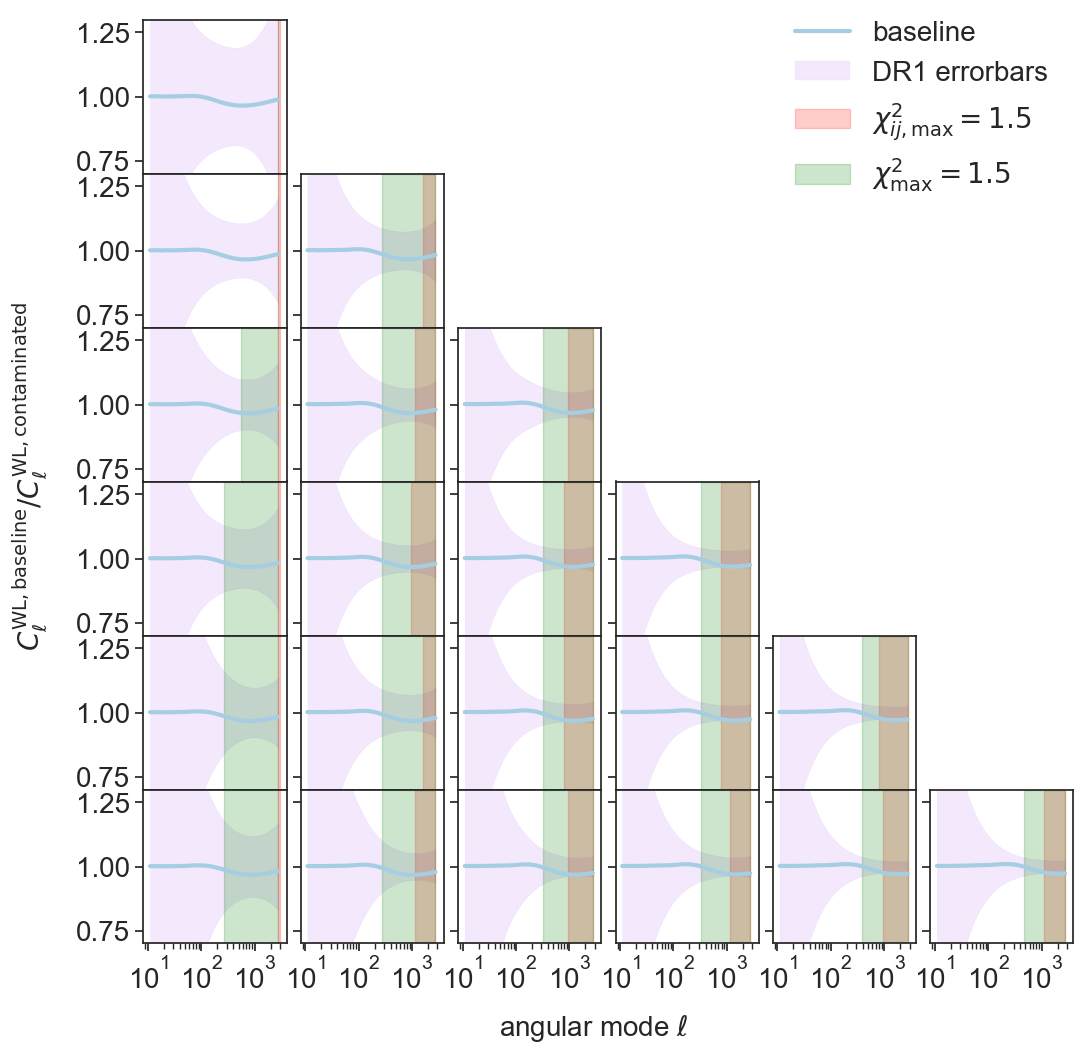

In [19]:
fig, ax = plt.subplots(n_she_bins, n_she_bins, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(n_she_bins):
    for j in range(n_she_bins):
        if i >= j:
            # find index of this pair
            p = pairs_wl.index((i, j))
            start = p * nell
            end = (p + 1) * nell
            err = errors_wl[start:end]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            y = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            ax[i,j].semilogx(ell_theory,  y, color='C0')


            diff = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]-cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            mask = ell_theory<ell_max_start
            chi2 = np.sum(diff[mask]**2/errors_wl[start:end][mask]**2)
            n = 1
            chi2_new = chi2
            mask_new = ell_theory < ell_max_start
            if chi2>chi2_max_ij:
                while chi2_new>chi2_max_ij:
                    mask_new = ell_theory < (ell_max_start - n)
                    chi2_new = np.sum(diff[mask_new]**2/errors_wl[start:end][mask_new]**2)
                    n +=1
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )


            ax[i, j].set_ylim(0.7, 1.3)

            ax[i, j].axvspan(xmin=ell_max_start - n, xmax=ell_theory[-1], color='red', alpha=0.2)
            ax[i, j].axvspan(xmin=ell_max_per_bin[f"bin {j+1}{i+1}"], xmax=ell_theory[-1], color='green', alpha=0.2)    
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm WL, baseline}_{\ell}/C^{\rm WL, contaminated}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(
    [
        'baseline',
        'DR1 errorbars',
        f'$\\chi^2_{{ij, \\rm max}}={chi2_max_ij}$',
        f'$\\chi^2_{{\\rm max}}={chi2_max}$'
    ],
    loc='upper right',
    ncol=1,
    bbox_to_anchor=(0.9, 0.9),
    bbox_transform=fig.transFigure,
    fontsize=20,
    frameon=False,
    title_fontsize=20
)

# Now let's add binned dark energy into the mix

### First plot information sources from Euclid

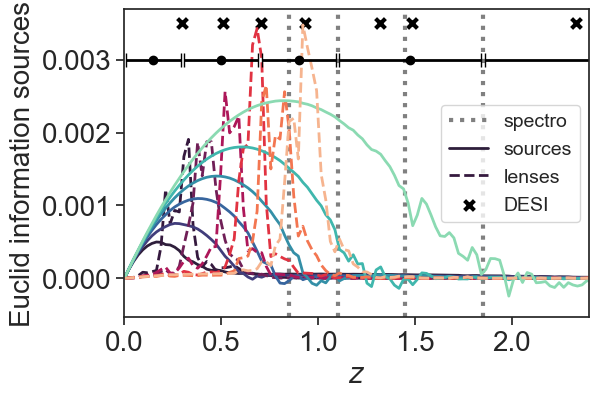

In [20]:
spectro_bin_edges = [0.85, 1.1, 1.45, 1.85]
spectro_redshifts = np.array([0.97, 1.27, 1.63])

best_guess_euclid_bins = [0., 0.3, 0.7, 1.1, 1.85, 1100]
guess_redshifts = [0.15, 0.5, 0.9, 0.5*(1.1+1.85), 0.5*(1.85+1100)]
guess_errors = [0.15-0.01, 0.2-0.01, 0.2-0.01, 0.5*(1.85-1.1)-0.01, 0.5*(1100-1.85)-0.01]

desi_redshifts = [0.295, 0.51, 0.706, 0.934, 1.321, 1.484, 2.330]
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# for i in range(6):
#     ax.plot(zs, my_dndz_she_norm[i], color=sns.color_palette("mako", len(dndz_she_norm))[i], label='sources' if i==0 else None)
#     ax.plot(zs, my_dndz_pos_norm[i], color=sns.color_palette("rocket", len(dndz_she_norm))[i], linestyle='--', label='lenses' if i==0 else None)
for i in range(4):
    ax.axvline(spectro_bin_edges[i], color='grey', linestyle=':', label='spectro' if i==0 else None)
for i in range(6):
    ax.plot(nonlinear_perturbations_cpl_hmcode.z, 
             tracer_shear.get_window(nonlinear_perturbations_cpl_hmcode.z)[i, :]*50, 
             linewidth=2, 
             color=sns.color_palette("mako", len(dndz_she_norm))[i], 
             label=f'sources' if i == 0 else "")
    ax.plot(nonlinear_perturbations_cpl_hmcode.z, 
             tracer_pos.get_window(nonlinear_perturbations_cpl_hmcode.z)[i, :], 
             linewidth=2, 
             color=sns.color_palette("rocket", len(dndz_she_norm))[i], 
             linestyle='--',
             label=f'lenses' if i == 0 else "")

ax.errorbar(
    guess_redshifts, 
    0.003*np.ones(len(guess_redshifts)), 
    xerr=guess_errors, 
    color='black', 
    linestyle='', 
    marker='o', 
    capsize=5,        # adds bars to the handles (horizontal error bar ends)
    elinewidth=2      # makes the error bar lines a bit thicker for visibility
)
ax.scatter(desi_redshifts, 0.0035*np.ones(len(desi_redshifts)), color='black', marker='x', s=50, label='DESI')
ax.set_xlim(0, 2.4)
ax.legend(loc='center right')
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'Euclid information sources')
plt.show()

### Now construct nodes and bins

In [21]:
from scipy.integrate import quad
from scipy.interpolate import make_interp_spline, CubicSpline

w0 = fiducial_cosmology['w0']
wa = fiducial_cosmology['wa']

def w_of_z(z, z_i, w_i):
    """
    Returns the equation of state as a function of redshift.

    Outside the knot range, w is held constant at the endpoint values:
    w_i[0] for z < z_i[0] and w_i[-1] for z > z_i[-1].
    """
    z = np.asarray(z)
    #spl_i = make_interp_spline(z_i, w_i)
    spl_i = CubicSpline(z_i, w_i)
    return spl_i(np.clip(z, z_i[0], z_i[-1]))
    #return spl_i(z)

def fde_of_z(z, z_i, fde_i):
    z = np.asarray(z)
    #spl_i = make_interp_spline(z_i, fde_i)
    spl_i = CubicSpline(z_i, fde_i)
    return spl_i(np.clip(z, z_i[0], z_i[-1]))

def w_of_z_cpl(z, w0, wa):
    z = np.asarray(z)
    return w0 + wa * z / (1.0 + z)
def fde_cpl(z, w0, wa):
    de_integrand = lambda zp: (1.0 + w_of_z_cpl(zp, w0, wa)) / (1.0 + zp)
    return np.exp(3.0 * quad(de_integrand, 0.0, float(z))[0])

zbin_edges = np.array([0., 0.3, 0.7, 1.1, 1.85, 1100])
zbin_centers = 0.5*(zbin_edges[1:] + zbin_edges[:-1])
zbin_widths = np.diff(np.array(zbin_edges))
w_i_bin_centers = np.array([w0+wa*(zbin_centers[i]/(1.+zbin_centers[i])) for i in range(len(zbin_centers))])
fde_i_bin_centers = np.array([fde_cpl(zbin_centers[i], w0, wa) for i in range(len(zbin_centers))])
n_bin = len(zbin_centers)


zbin_nodes = zbin_edges[:-1]
w_i_nodes = np.array([w0+wa*(zbin_nodes[i]/(1.+zbin_nodes[i])) for i in range(len(zbin_nodes))])
fde_i_nodes = np.array([fde_cpl(zbin_nodes[i], w0, wa) for i in range(len(zbin_nodes))])

print('for step-function (without smoothing:')
print('w_i_centers: ', w_i_bin_centers)
print('fde_i_centers: ', fde_i_bin_centers)
print('z-bin edges: ', zbin_edges)
print('z-bin widths: ', zbin_widths)
print('z-bin centers: ', zbin_centers)
print('Nbin: ', n_bin, len(w_i_bin_centers))

for step-function (without smoothing:
w_i_centers:  [-0.76521739 -0.86666667 -0.93684211 -0.9979798  -1.19909408]
fde_i_centers:  [1.1182836  1.29268433 1.38460373 1.41934452 0.10118902]
z-bin edges:  [0.00e+00 3.00e-01 7.00e-01 1.10e+00 1.85e+00 1.10e+03]
z-bin widths:  [3.00000e-01 4.00000e-01 4.00000e-01 7.50000e-01 1.09815e+03]
z-bin centers:  [1.50000e-01 5.00000e-01 9.00000e-01 1.47500e+00 5.50925e+02]
Nbin:  5 5


In [22]:
from cloelib.cosmology.binned_wz_cosmology import DEBinnedEoSBackground, DEBinnedEoSLinearPerturbations, DEBinnedEoSNonlinearPerturbations
from cloelib.cosmology.binned_fdez_cosmology import DEBinnedDensityBackground, DEBinnedDensityLinearPerturbations, DEBinnedDensityNonlinearPerturbations
from cloelib.cosmology.splined_wz_cosmology import DESplinedEoSBackground, DESplinedEoSLinearPerturbations, DESplinedEoSNonlinearPerturbations
from cloelib.cosmology.splined_fdez_cosmology import DESplinedDensityBackground, DESplinedDensityLinearPerturbations, DESplinedDensityNonlinearPerturbations

Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator..

In [23]:
cosmo_dict = {
    'H0': fiducial_cosmology['H0'], 
    'Omega_cdm0': fiducial_cosmology['Omega_cdm0'], 
    'Omega_b0': fiducial_cosmology['Omega_b0'], 
    'Omega_k0': fiducial_cosmology['Omega_k0'], 
    'ns': fiducial_cosmology['ns'], 
    'As': fiducial_cosmology['As'],
    'mnu': fiducial_cosmology['mnu'],
}

background_binned_wz = DEBinnedEoSBackground(cosmo_dict,
                            zbin_edges = zbin_edges,
                            w_i = w_i_bin_centers
                            )
background_binned_fde = DEBinnedDensityBackground(cosmo_dict,
                            zbin_edges = zbin_edges,
                            fde_i = fde_i_bin_centers
                            )
background_splined_wz = DESplinedEoSBackground(cosmo_dict,
                            z_i = zbin_nodes,
                            w_i = w_i_nodes
                            )
background_splined_fde = DESplinedDensityBackground(cosmo_dict,
                            z_i = zbin_nodes,
                            fde_i = fde_i_nodes
                            )

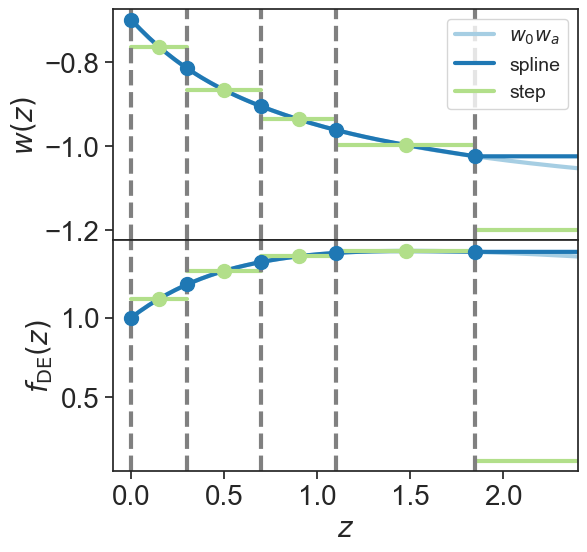

In [24]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 6), sharex=True, 
                                gridspec_kw={'height_ratios': [1, 1], 'hspace': 0})
ax[0].errorbar(zbin_nodes,  w_i_nodes,   marker='o',  markersize=10, linestyle='',color='C1')
ax[1].errorbar(zbin_nodes, fde_i_nodes,   marker='o',  markersize=10, linestyle='',color='C1')
ax[0].plot(zs, w0+wa*(zs/(1.+zs)), label='$w_0w_a$', color='C0')
ax[1].plot(zs, [fde_cpl(zs_i, w0, wa) for zs_i in zs], label='$w_0w_a$', color='C0')
ax[0].plot(zs, w_of_z(zs, zbin_nodes, w_i_nodes), label='spline', color='C1')
ax[1].plot(zs, fde_of_z(zs, zbin_nodes, fde_i_nodes),  color='C1')

ax[0].errorbar(zbin_centers, w_i_bin_centers,   marker='o',  markersize=10, linestyle='',color='C2')
ax[1].errorbar(zbin_centers, fde_i_bin_centers,   marker='o',  markersize=10, linestyle='',color='C2')
for i in range(5):
    z_arr = np.linspace(zbin_edges[i], zbin_edges[i+1], 10)
    ax[0].plot(z_arr, w_i_bin_centers[i]*np.ones(10), color='C2', label='step' if i==0 else '')
    ax[1].plot(z_arr, fde_i_bin_centers[i]*np.ones(10), color='C2')


for i in range(len(zbin_edges)):
    ax[0].axvline(zbin_edges[i], ls='--', color='grey')
    ax[1].axvline(zbin_edges[i], ls='--', color='grey')
ax[1].set_xlabel('$z$')
ax[0].set_ylabel('$w(z)$')
ax[1].set_ylabel(r'$f_{\rm DE}(z)$')
ax[0].set_xlim(-0.1, 2.4)
ax[0].legend()
plt.show()

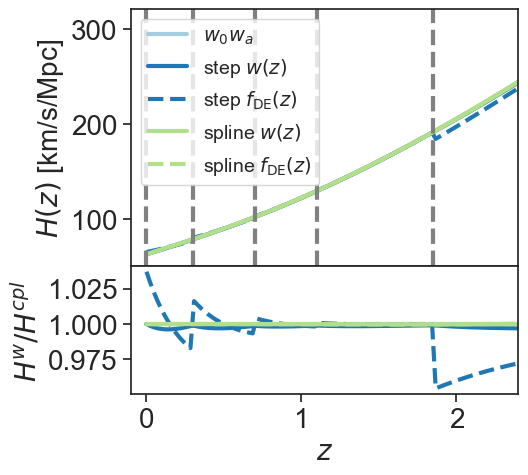

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.hubble_parameter(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_binned_wz.hubble_parameter(zs), label='step $w(z)$', color='C1', linestyle='-')
ax1.plot(zs, background_binned_fde.hubble_parameter(zs), label=r'step $f_{\rm DE}(z)$', color='C1', linestyle='--')
ax1.plot(zs, background_splined_wz.hubble_parameter(zs), label='spline $w(z)$', color='C2', linestyle='-')
ax1.plot(zs, background_splined_fde.hubble_parameter(zs), label=r'spline $f_{\rm DE}(z)$', color='C2', linestyle='--')


ax2.plot(zs, background_cpl.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_binned_wz.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label='step $w(z)$', color='C1', linestyle='-')
ax2.plot(zs, background_binned_fde.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label=r'step $f_{\rm DE}(z)$', color='C1', linestyle='--')
ax2.plot(zs, background_splined_wz.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label='spline $w(z)$', color='C2', linestyle='-')
ax2.plot(zs, background_splined_fde.hubble_parameter(zs)/background_cpl.hubble_parameter(zs), label=r'spline $f_{\rm DE}(z)$', color='C2', linestyle='--')


for i in range(len(zbin_edges)):
    ax1.axvline(zbin_edges[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$H(z)$ [km/s/Mpc]')
ax2.set_ylabel('$H^{w}/H^{cpl}$')
ax2.set_xlim(-0.1, 2.4)
ax1.legend()
plt.show()

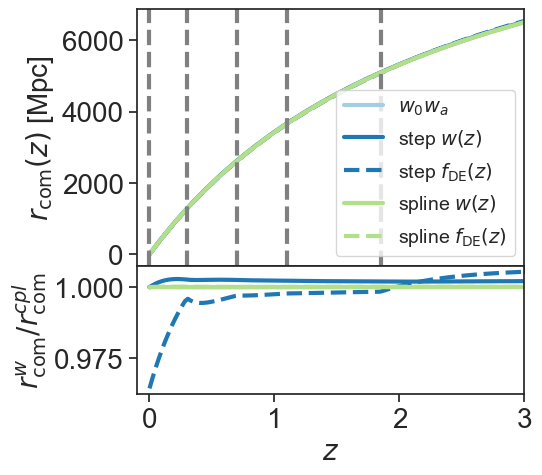

In [26]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
ax1.plot(zs, background_cpl.comoving_distance(zs), label='$w_0w_a$', color='C0')
ax1.plot(zs, background_binned_wz.comoving_distance(zs), label='step $w(z)$', color='C1', linestyle='-')
ax1.plot(zs, background_binned_fde.comoving_distance(zs), label=r'step $f_{\rm DE}(z)$', color='C1', linestyle='--')
ax1.plot(zs, background_splined_wz.comoving_distance(zs), label='spline $w(z)$', color='C2', linestyle='-')
ax1.plot(zs, background_splined_fde.comoving_distance(zs), label=r'spline $f_{\rm DE}(z)$', color='C2', linestyle='--')

ax2.plot(zs, background_cpl.comoving_distance(zs)/background_cpl.comoving_distance(zs), label='$w_0w_a$', color='C0')
ax2.plot(zs, background_binned_wz.comoving_distance(zs)/background_cpl.comoving_distance(zs), label='step $w(z)$', color='C1', linestyle='-')
ax2.plot(zs, background_binned_fde.comoving_distance(zs)/background_cpl.comoving_distance(zs), label=r'step $f_{\rm DE}(z)$', color='C1', linestyle='--')
ax2.plot(zs, background_splined_wz.comoving_distance(zs)/background_cpl.comoving_distance(zs), label='spline $w(z)$', color='C2', linestyle='-')
ax2.plot(zs, background_splined_fde.comoving_distance(zs)/background_cpl.comoving_distance(zs), label=r'spline $f_{\rm DE}(z)$', color='C2', linestyle='--')


for i in range(len(zbin_nodes)):
    ax1.axvline(zbin_nodes[i], ls='--', color='grey')

ax2.set_xlabel('$z$')
ax1.set_ylabel('$r_{\\rm com}(z)$ [Mpc]')
ax2.set_ylabel('$r_{\\rm com}^{w}/r_{\\rm com}^{cpl}$')
ax2.set_xlim(-0.1, 3)
#ax2.set_ylim(0.99, 1.01)
ax1.legend()
plt.show()

In [27]:
linear_perturbations_splined_wz = DESplinedEoSLinearPerturbations(background_splined_wz, linear_perturbations_lcdm_hmcode)
linear_perturbations_splined_fde = DESplinedDensityLinearPerturbations(background_splined_fde, linear_perturbations_lcdm_hmcode)
nonlinear_perturbations_splined_wz = DESplinedEoSNonlinearPerturbations(background_splined_wz, linear_perturbations_splined_wz, zs, log10TAGN=None)
nonlinear_perturbations_splined_fde = DESplinedDensityNonlinearPerturbations(background_splined_fde, linear_perturbations_splined_fde, zs, log10TAGN=None)


linear_perturbations_binned_wz = DEBinnedEoSLinearPerturbations(background_binned_wz, linear_perturbations_lcdm_hmcode)
linear_perturbations_binned_fde = DEBinnedDensityLinearPerturbations(background_binned_fde, linear_perturbations_lcdm_hmcode)
nonlinear_perturbations_binned_wz = DEBinnedEoSNonlinearPerturbations(background_binned_wz, linear_perturbations_binned_wz, zs, log10TAGN=None)
nonlinear_perturbations_binned_fde = DEBinnedDensityNonlinearPerturbations(background_binned_fde, linear_perturbations_binned_fde, zs, log10TAGN=None)

In [28]:
ks = np.logspace(np.log10(1e-3), np.log10(5), 100)
ps_nonlin_cpl = nonlinear_perturbations_cpl_hmcode.matter_power_spectrum(0, ks)
ps_nonlin_binned_wz = nonlinear_perturbations_binned_wz.matter_power_spectrum(0, ks)
ps_nonlin_binned_fde = nonlinear_perturbations_binned_fde.matter_power_spectrum(0, ks)
ps_nonlin_splined_wz = nonlinear_perturbations_splined_wz.matter_power_spectrum(0, ks)
ps_nonlin_splined_fde = nonlinear_perturbations_splined_fde.matter_power_spectrum(0, ks)


(0.95, 1.15)

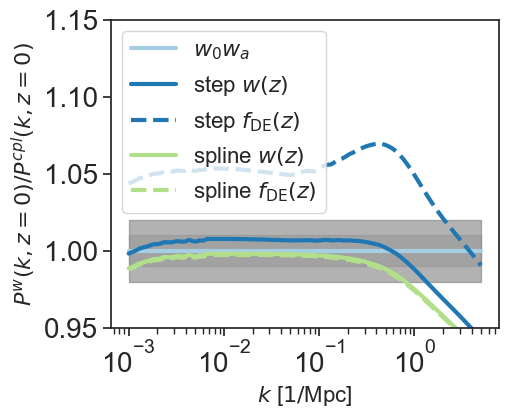

In [29]:
# Create the figure
plt.figure(figsize=(5, 4))

plt.semilogx(ks, ps_nonlin_cpl[0]/ps_nonlin_cpl[0], color='C0', label='$w_0w_a$' )
plt.semilogx(ks, ps_nonlin_binned_wz[0]/ps_nonlin_cpl[0], color='C1', label='step $w(z)$' )
plt.semilogx(ks, ps_nonlin_binned_fde[0]/ps_nonlin_cpl[0], color='C1', linestyle='--', label=r'step $f_{\rm DE}(z)$')
plt.semilogx(ks, ps_nonlin_splined_wz[0]/ps_nonlin_cpl[0], color='C2', label='spline $w(z)$' )
plt.semilogx(ks, ps_nonlin_splined_fde[0]/ps_nonlin_cpl[0], color='C2', linestyle='--', label=r'spline $f_{\rm DE}(z)$')

plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$P^{w}(k, z=0)/P^{cpl}(k, z=0)$', fontsize = 16)
plt.fill_between(ks, 0.98*np.ones(len(ks)), 1.02*np.ones(len(ks)), color='grey', alpha=0.6)
plt.fill_between(ks, 0.99*np.ones(len(ks)), 1.01*np.ones(len(ks)), color='grey', alpha=0.3)
plt.legend(fontsize = 16, loc='upper left')
plt.ylim(0.95, 1.15)

# Since we want to study the non-standard part of modelling only, the contaminated vector is HMcode CPL not BACCO CPL

### We also pick only bineed and splined $w(z)$ and will later derive $f(z)$ from them

In [30]:
nonlinear_perturbations_contaminated = nonlinear_perturbations_cpl_hmcode
nonlinear_perturbations_baseline = nonlinear_perturbations_binned_wz
#nonlinear_perturbations_baseline = nonlinear_perturbations_binned_fde
#nonlinear_perturbations_baseline = nonlinear_perturbations_splined_wz
#nonlinear_perturbations_baseline = nonlinear_perturbations_splined_fde

for label in labels:
    perturbations = eval(f'nonlinear_perturbations_{label}')
    cells_wl[label], cells_ggl[label], cells_gc[label] = compute_cells(perturbations)

In [31]:
data = np.array(
            [cells_wl['contaminated'][key][0, 0] for key in WL_keys]
        ).flatten()
theory = np.array(
            [cells_wl['baseline'][key][0, 0] for key in WL_keys]
        ).flatten()
C = cov_WL

diff = theory - data
invC = np.linalg.inv(C)

chi2 = diff @ invC @ diff
chi2

np.float64(6.2699910915434245)

In [32]:
# Per-point chi^2 contribution for each tomographic bin pair.
# Using the full-cov decomposition:  chi2 = sum_i diff_i * (invC @ diff)_i
v = invC @ diff
chi2_per_point = diff * v  # shape: (n_pairs * nell,)
assert np.isclose(chi2_per_point.sum(), chi2), "per-point sum must match total chi2"
chi2_contribution = {}
for p, key in enumerate(WL_keys):
    _, _, i, j = key
    start = p * nell
    end = (p + 1) * nell
    chi2_contribution[f"bin {i}{j}"] = {
        "ell":  ell_theory.tolist(),
        "chi2": chi2_per_point[start:end].tolist(),
    }
print(f"Total chi2                       = {chi2:.4f}")
print(f"Sum of per-point contributions   = "
      f"{sum(sum(b['chi2']) for b in chi2_contribution.values()):.4f}")
for bin_label, vals in chi2_contribution.items():
    print(f"  {bin_label}: chi2 = {sum(vals['chi2']):.4f}")

Total chi2                       = 6.2700
Sum of per-point contributions   = 6.2700
  bin 11: chi2 = 0.0571
  bin 12: chi2 = 0.1437
  bin 13: chi2 = 0.1465
  bin 14: chi2 = 0.1416
  bin 15: chi2 = 0.1339
  bin 16: chi2 = 0.1217
  bin 22: chi2 = 0.1242
  bin 23: chi2 = 0.3024
  bin 24: chi2 = 0.3024
  bin 25: chi2 = 0.2845
  bin 26: chi2 = 0.2601
  bin 33: chi2 = 0.2203
  bin 34: chi2 = 0.4796
  bin 35: chi2 = 0.4515
  bin 36: chi2 = 0.3856
  bin 44: chi2 = 0.2833
  bin 45: chi2 = 0.5654
  bin 46: chi2 = 0.4407
  bin 55: chi2 = 0.3164
  bin 56: chi2 = 0.5625
  bin 66: chi2 = 0.5467


In [33]:
chi2_max = 1.5

# Tag every global data-vector index with (bin_label, ell, bin_idx, ell_idx).
# bin_idx is the position of the (i, j) pair inside WL_keys; ell_idx is the
# index into ell_theory.  This lets us enforce the "remove only from the
# high-ell end of each bin" constraint, so kept ells stay contiguous from
# l_min upward in every bin.
point_tags = []
for p, key in enumerate(WL_keys):
    _, _, i, j = key
    bin_label = f"bin {i}{j}"
    for k, ell_val in enumerate(ell_theory):
        point_tags.append((bin_label, float(ell_val), p, k))

keep_mask = np.ones(len(diff), dtype=bool)

def chi2_with_mask(mask):
    """Recompute chi2 and per-point contributions on the *kept* subset by
    inverting the corresponding sub-covariance."""
    d_sub    = diff[mask]
    C_sub    = C[np.ix_(mask, mask)]
    invC_sub = np.linalg.inv(C_sub)
    v_sub    = invC_sub @ d_sub
    return d_sub @ v_sub, d_sub * v_sub

chi2_cur, per_point_cur = chi2_with_mask(keep_mask)
print(f"Initial chi2 = {chi2_cur:.4f}   (n_points = {keep_mask.sum()})\n")

# For every bin (position p in WL_keys), track its highest currently kept
# ell-index.  Only that point is eligible for removal at any step.
highest_kept = {p: nell - 1 for p in range(len(WL_keys))}

removed = []
max_iter = len(diff)  # safety cap

while chi2_cur > chi2_max and len(removed) < max_iter:
    # Map per-point contributions (over kept subarray) back to global indices.
    active_global  = np.where(keep_mask)[0]
    contrib_global = np.full(len(diff), -np.inf)
    contrib_global[active_global] = per_point_cur

    # Candidates: for each bin still having points, the contribution at its
    # current highest-ell index.
    candidates = []
    for p, k_top in highest_kept.items():
        if k_top is None:
            continue
        g = p * nell + k_top
        candidates.append((contrib_global[g], g, p, k_top))

    if not candidates:
        print("All points removed; stopping.")
        break

    # Pick the eligible high-ell point with the largest chi2 contribution.
    best_contrib, worst_global, p, k_top = max(candidates, key=lambda t: t[0])

    if best_contrib <= 0:
        print("No high-ell candidate has positive chi2 contribution; stopping.")
        break

    bin_label, ell_val, _, _ = point_tags[worst_global]
    keep_mask[worst_global] = False
    highest_kept[p] = k_top - 1 if k_top > 0 else None

    chi2_cur, per_point_cur = chi2_with_mask(keep_mask)

    removed.append({
        "bin":        bin_label,
        "ell":        ell_val,
        "chi2_after": float(chi2_cur),
    })
    print(f"  removed {bin_label:>8s}, ell = {ell_val:10.4f}  "
          f"->  new chi2 = {chi2_cur:.4f}   "
          f"(n_points left = {keep_mask.sum()})")

print(f"\nFinal chi2 = {chi2_cur:.4f}  after removing {len(removed)} points "
      f"(threshold = {chi2_max}).")

# Per-bin ell_max after the cut, handy for downstream use.
ell_max_per_bin = {}
for p, key in enumerate(WL_keys):
    _, _, i, j = key
    k_top = highest_kept[p]
    ell_max_per_bin[f"bin {i}{j}"] = float(ell_theory[k_top]) if k_top is not None else None
print("\nell_max retained per bin:")
for b, e in ell_max_per_bin.items():
    print(f"  {b}: ell_max = {e}")

Initial chi2 = 6.2700   (n_points = 672)

  removed   bin 56, ell =  2755.1084  ->  new chi2 = 6.1352   (n_points left = 671)
  removed   bin 46, ell =  2755.1084  ->  new chi2 = 5.9846   (n_points left = 670)
  removed   bin 45, ell =  2755.1084  ->  new chi2 = 5.8078   (n_points left = 669)
  removed   bin 36, ell =  2755.1084  ->  new chi2 = 5.6762   (n_points left = 668)
  removed   bin 35, ell =  2755.1084  ->  new chi2 = 5.5221   (n_points left = 667)
  removed   bin 34, ell =  2755.1084  ->  new chi2 = 5.3614   (n_points left = 666)
  removed   bin 55, ell =  2755.1084  ->  new chi2 = 5.2069   (n_points left = 665)
  removed   bin 66, ell =  2755.1084  ->  new chi2 = 5.0567   (n_points left = 664)
  removed   bin 46, ell =  2305.3063  ->  new chi2 = 4.9812   (n_points left = 663)
  removed   bin 45, ell =  2305.3063  ->  new chi2 = 4.8876   (n_points left = 662)
  removed   bin 56, ell =  2305.3063  ->  new chi2 = 4.7988   (n_points left = 661)
  removed   bin 36, ell =  2305.30

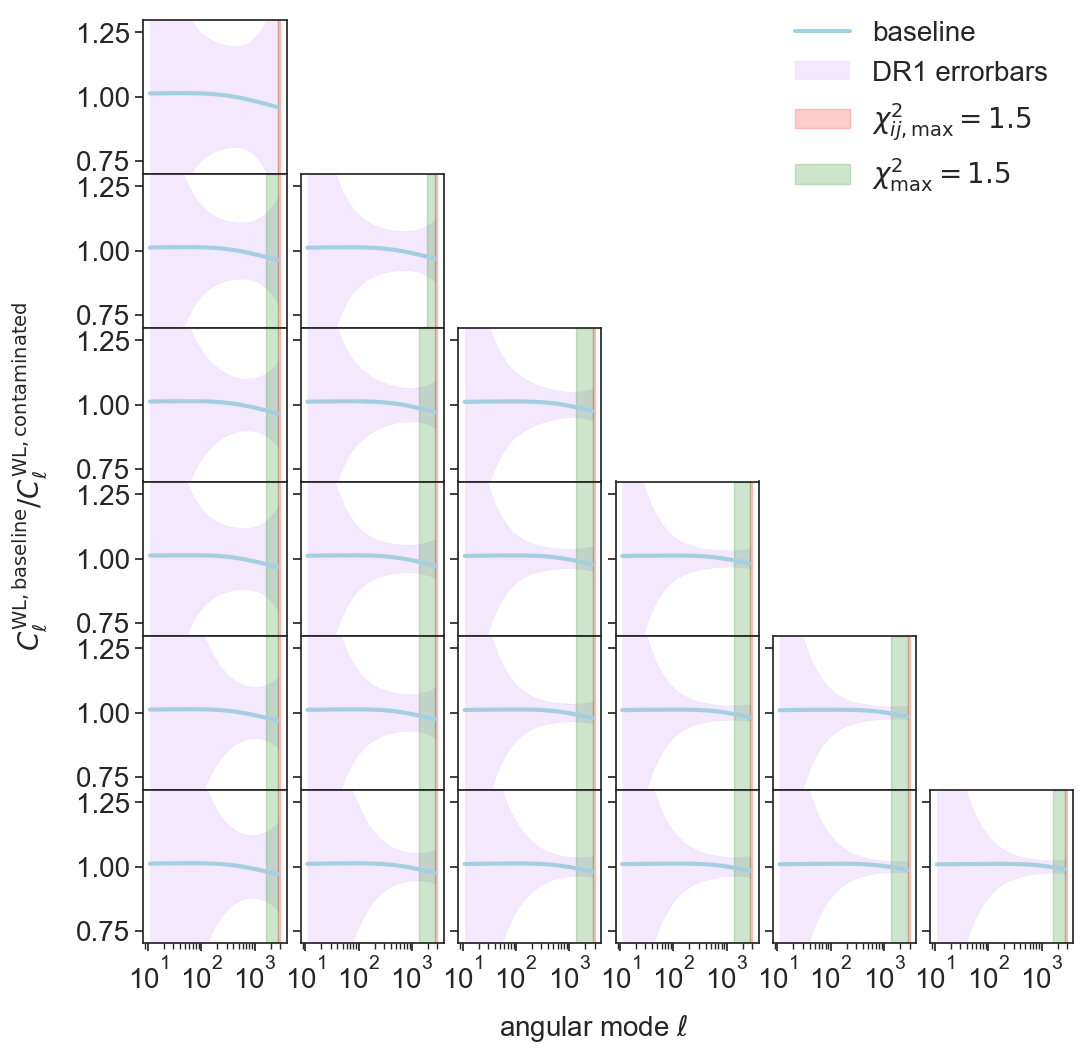

In [34]:
fig, ax = plt.subplots(n_she_bins, n_she_bins, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(n_she_bins):
    for j in range(n_she_bins):
        if i >= j:
            # find index of this pair
            p = pairs_wl.index((i, j))
            start = p * nell
            end = (p + 1) * nell
            err = errors_wl[start:end]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            y = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]/cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            ax[i,j].semilogx(ell_theory,  y, color='C0')


            diff = cells_wl['baseline'][('SHE', 'SHE', j+1, i+1)][0, 0]-cells_wl['contaminated'][('SHE', 'SHE', j+1, i+1)][0, 0]
            mask = ell_theory<ell_max_start
            chi2 = np.sum(diff[mask]**2/errors_wl[start:end][mask]**2)
            n = 1
            chi2_new = chi2
            mask_new = ell_theory < ell_max_start
            if chi2>chi2_max_ij:
                while chi2_new>chi2_max_ij:
                    mask_new = ell_theory < (ell_max_start - n)
                    chi2_new = np.sum(diff[mask_new]**2/errors_wl[start:end][mask_new]**2)
                    n +=1
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )


            ax[i, j].set_ylim(0.7, 1.3)

            ax[i, j].axvspan(xmin=ell_max_start - n, xmax=ell_theory[-1], color='red', alpha=0.2)
            ax[i, j].axvspan(xmin=ell_max_per_bin[f"bin {j+1}{i+1}"], xmax=ell_theory[-1], color='green', alpha=0.2)    
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm WL, baseline}_{\ell}/C^{\rm WL, contaminated}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(
    [
        'baseline',
        'DR1 errorbars',
        f'$\\chi^2_{{ij, \\rm max}}={chi2_max_ij}$',
        f'$\\chi^2_{{\\rm max}}={chi2_max}$'
    ],
    loc='upper right',
    ncol=1,
    bbox_to_anchor=(0.9, 0.9),
    bbox_transform=fig.transFigure,
    fontsize=20,
    frameon=False,
    title_fontsize=20
)